In [1]:
# ==========================================================
# IMPORTS
# ==========================================================

import os
import importlib
import time
import pickle
import numpy as np
from tqdm import tqdm
from map_elites.map_elites_balance import MAPElites
from simulation.simulation_final import HexapodTorqueSimulation, evaluate_batch_parallel_torque
from controllers.hexapod_controller_final import RecurrentTorqueHexapodController
from config import URDF_PATH
import torch
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
import config as experiment_config

pybullet build time: Jan 29 2025 23:17:20


In [2]:
# ==========================================================
# PROJECT PATHS (synchronized with config.py)
# ==========================================================

# Prefer canonical paths defined in config.py (experiment_config) if available
PROJECT_ROOT = getattr(experiment_config, 'PROJECT_ROOT', os.getcwd())
RESULTS_DIR = getattr(experiment_config, 'RESULTS_DIR', os.path.join(PROJECT_ROOT, "results"))


# ==========================================================
# CONTROLLER
# ==========================================================

# Controller genome size - prefer value from config module
CONTROLLER_GENOME_SIZE = getattr(experiment_config, 'CONTROLLER_GENOME_SIZE', RecurrentTorqueHexapodController.get_genome_size())

print("=" * 60)
print("PROJECT CONFIGURATION")
print("=" * 60)

print(f"PROJECT_ROOT: {PROJECT_ROOT}")
print(f"URDF_PATH: {getattr(experiment_config, 'URDF_PATH', URDF_PATH)}")
print(f"URDF exists: {os.path.exists(getattr(experiment_config, 'URDF_PATH', URDF_PATH))}")

print(f"Genome size: {CONTROLLER_GENOME_SIZE}")

# ==========================================================
# BEHAVIOR DESCRIPTOR (from config.py) + local fitness configuration
# ==========================================================

BD_MODE = 'xy_position'  # Options: 'xy_position', 'duty_factor', 'transformer_latent', 'transformer8d'
print(f"Behavior Descriptor Mode: {BD_MODE}")

# Keep config.py as the source of truth, but sync its module globals to the notebook choice.
experiment_config.BD_MODE = BD_MODE
experiment_config.TRANSFORMER_BD_CONFIG = (
    experiment_config.get_transformer_bd_config(BD_MODE)
    if BD_MODE.startswith('transformer')
    else None
)

# Fitness configuration is intentionally local to the notebook.
FITNESS_MODE = 'combined'  # Options: 'combined', 'distance', 'forward_velocity', 'avg_speed', 'stability'
DISTANCE_WEIGHT = 5.0 #3.0
AVG_SPEED_WEIGHT = 0.8 #0.3
STABILITY_PENALTY_WEIGHT = 0.05 #0.2
ENERGY_WEIGHT = 2e-8 #2e-6

def get_fitness_name(mode=None):
    if mode is None:
        mode = FITNESS_MODE

    if mode == 'combined':
        return 'Combined'
    elif mode == 'distance':
        return 'Distance_Traveled'
    elif mode == 'forward_velocity':
        return 'Forward_velocity'
    elif mode == 'avg_speed':
        return 'Average_speed'
    elif mode == 'stability':
        return 'Stability_score'
    else:
        raise ValueError(f"Unknown FITNESS_MODE '{mode}'")

# Keep using the functions from config.py.
get_behavior_descriptor_dims = experiment_config.get_behavior_descriptor_dims
get_behavior_descriptor_names = experiment_config.get_behavior_descriptor_names
TRANSFORMER_BD_CONFIG = experiment_config.TRANSFORMER_BD_CONFIG

# ==========================================================
# MAP-ELITES CONFIGURATION (local experiment override)
# ==========================================================

MAP_ELITES_CONFIG = {
    'behavior_descriptors_dims': get_behavior_descriptor_dims(),
    'genome_size': CONTROLLER_GENOME_SIZE,
    'genome_bounds': (-3, 3),
    'num_initial_random': 5000,
    'num_iterations': 5000,
    'batch_size': 64,
    'mutation_rate': 0.005,
    'mutation_strength': 0.08,
    'bd_handling': 'clip' if BD_MODE.startswith('transformer') else 'reject',
    'num_repeated_evaluations': 3,
    'seed': 42,
}
print(behaviour_descriptors_dims := MAP_ELITES_CONFIG['behavior_descriptors_dims'])

# ==========================================================
# LOGGING CONFIGURATION (local experiment override)
# ==========================================================

LOGGING_CONFIG = {
    'save_interval': 500,
    'trajectory_save_interval': 500,
    'save_random_trajectories': True,
    'trajectory_save_probability': 0.1,
    'print_interval': 1000,
    'save_grid': True,
    'save_plots': True,
    'save_detailed_logs': False,
    'num_best_to_log': 20,
    'num_random_to_log': 20,
}

experiment_config.LOGGING_CONFIG = LOGGING_CONFIG

# ==========================================================
# SIMULATION CONFIGURATION (local experiment override)
# ==========================================================

SIMULATION_CONFIG = {
    'duration': 6.0,
    'time_step': 1.0 / 240,
    'gui': False,
    'max_force': 5.0,
    'sample_interval': 1.0,
    'acceleration_threshold': 20.0,
    'warmup_time': 1.0,
    'controller_interval': 4,
}

experiment_name = f"map_elites_{BD_MODE}_{get_fitness_name()}_fitness"
RESULTS_DIR = os.path.join(RESULTS_DIR, experiment_name)
os.makedirs(RESULTS_DIR, exist_ok=True)
CHECKPOINT_DIR = os.path.join(RESULTS_DIR, "checkpoints")
os.makedirs(CHECKPOINT_DIR, exist_ok=True)
RANDOM_TRAJECTORIES_DIR = os.path.join(RESULTS_DIR, "random_trajectories")
os.makedirs(RANDOM_TRAJECTORIES_DIR, exist_ok=True)
DETAILED_LOGS_DIR = os.path.join(RESULTS_DIR, "detailed_logs")
os.makedirs(DETAILED_LOGS_DIR, exist_ok=True)

RESUME = False
CHECKPOINT = os.path.join(
    CHECKPOINT_DIR,
    "map_elites_iter_4500.pkl"
)

start_iteration = 0

if RESUME:
    print(CHECKPOINT)
    start_iteration = 4501

PROJECT CONFIGURATION
PROJECT_ROOT: /home/joze/Mestrado/Dissertacao/Pybullet
URDF_PATH: /home/joze/Mestrado/Dissertacao/Pybullet/robot_models/hexapod.urdf
URDF exists: True
Genome size: 3282
Behavior Descriptor Mode: xy_position
[(-3, 3, 50), (-3, 3, 50)]


In [3]:
# ==========================================================
# DETAILED LOG EXPORT HELPERS
# ==========================================================

def save_detailed_logs_snapshot(map_elites, sim, iteration, num_best=20):
    cells = list(map_elites.grid.values())
    if not cells:
        print(f"No archive cells available to log at iteration {iteration}.")
        return None

    cells_sorted = sorted(cells, key=lambda x: x['fitness'], reverse=True)
    best_cells = cells_sorted[:num_best]

    detailed_logs_data = []
    for rank, cell in enumerate(best_cells, start=1):
        result = sim.evaluate_controller(
            cell['genome'],
            duration=SIMULATION_CONFIG['duration'],
            warmup_time=SIMULATION_CONFIG.get('warmup_time', 1.0),
            render=False,
            sample_interval=SIMULATION_CONFIG['sample_interval'],
            controller_interval=SIMULATION_CONFIG.get('controller_interval', 4),
            log_all_steps=True,
        )

        detailed_logs_data.append({
            'rank': rank,
            'fitness': float(cell['fitness']),
            # archive BD (from the cell) and run-computed BD (from evaluate_controller)
            'archive_behavior_descriptors': cell.get('bd'),
            'behavior_descriptors': result.get('behavior_descriptors', cell.get('bd')),
            'genome': cell['genome'],
            'detailed_log': result.get('detailed_log', []),
            'distance': float(result.get('distance', 0.0)),
            'energy': float(result.get('energy', 0.0)),
        })

    os.makedirs(DETAILED_LOGS_DIR, exist_ok=True)
    log_path = os.path.join(DETAILED_LOGS_DIR, f"detailed_logs_iter_{iteration}.pkl")
    with open(log_path, 'wb') as f:
        pickle.dump(detailed_logs_data, f)

    print(f"Saved detailed logs: {log_path} ({len(detailed_logs_data)} controllers)")
    return log_path

XY

In [4]:
# ==========================================================
# CREATE MAP-ELITES
# ==========================================================

map_elites = MAPElites(
    behavior_descriptors_dims=MAP_ELITES_CONFIG['behavior_descriptors_dims'],
    genome_size=MAP_ELITES_CONFIG['genome_size'],
    genome_bounds=MAP_ELITES_CONFIG['genome_bounds'],
    bd_handling=MAP_ELITES_CONFIG['bd_handling'],
    seed=MAP_ELITES_CONFIG['seed'],
)

if RESUME and os.path.exists(CHECKPOINT):
    map_elites.load(CHECKPOINT)
    print(f"Resumed from {CHECKPOINT}")

else:

    map_elites.bd_mode = BD_MODE
    map_elites.fitness_mode = FITNESS_MODE
    map_elites.bd_labels = get_behavior_descriptor_names()
    map_elites.fitness_label = get_fitness_name()

    # ==========================================================
    # INITIAL RANDOM POPULATION
    # ==========================================================

    initial_population = []

    for _ in tqdm(
        range(MAP_ELITES_CONFIG['num_initial_random']),
        desc="Generating initial population"
    ):
        initial_population.append(map_elites.random_genome())

    # ==========================================================
    # EVALUATE INITIAL POPULATION
    # ==========================================================

    fitnesses, bds, final_positions, distances, average_speeds, energies, stability_penalties = evaluate_batch_parallel_torque(initial_population)

    # ==========================================================
    # ADD TO ARCHIVE
    # ==========================================================

    for genome, fitness, bd, final_position in tqdm(
        zip(initial_population, fitnesses, bds, final_positions),
        desc="Adding initial population to archive",
        total=len(initial_population)
    ):
        map_elites.add_to_grid(genome, fitness, bd, final_position=final_position)

    # ==========================================================
    # INITIAL STATS
    # ==========================================================

    stats = map_elites.get_statistics()

    print("\nInitial archive statistics:\n")

    for k, v in stats.items():
        print(f"{k}: {v}")

    # ==========================================================
    # TIMER
    # ==========================================================

    start_time = time.time()

Generating initial population:   0%|          | 0/5000 [00:00<?, ?it/s]

Adding initial population to archive: 100%|██████████| 5000/5000 [00:00<00:00, 181091.83it/s]


Initial archive statistics:

coverage: 0.0488
num_filled: 122
max_fitness: 0.9832081991459368
mean_fitness: 0.5478257925754257
qd_score: 66.83474669420194


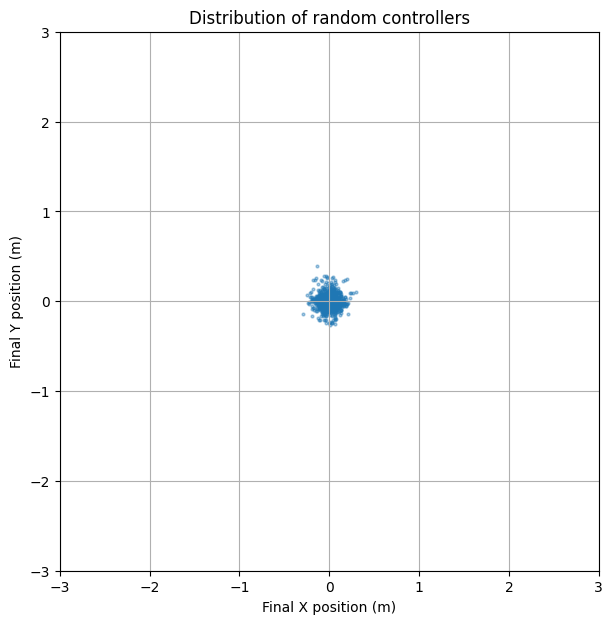

Unique cells visited: 25
Archive cells: 2500
Coverage from random controllers: 1.00%


In [6]:
import matplotlib.pyplot as plt
import numpy as np

bds = np.asarray(bds)

plt.figure(figsize=(7, 7))
plt.scatter(
    bds[:, 0],
    bds[:, 1],
    s=4,
    alpha=0.4
)

plt.xlabel("Final X position (m)")
plt.ylabel("Final Y position (m)")
plt.title("Distribution of random controllers")

# Show archive limits
x_low, x_high, _ = MAP_ELITES_CONFIG['behavior_descriptors_dims'][0]
y_low, y_high, _ = MAP_ELITES_CONFIG['behavior_descriptors_dims'][1]

plt.xlim(x_low, x_high)
plt.ylim(y_low, y_high)

plt.grid(True)
plt.gca().set_aspect('equal')

plt.show()

visited_cells = set()

for bd in bds:
    norm_bd = map_elites.process_behavior_descriptors(bd)

    if norm_bd is None:
        continue

    idx = map_elites.get_grid_index(norm_bd)

    if idx is not None:
        visited_cells.add(tuple(idx))

print(f"Unique cells visited: {len(visited_cells)}")
print(f"Archive cells: {map_elites.get_total_cells()}")
print(f"Coverage from random controllers: "
      f"{100*len(visited_cells)/map_elites.get_total_cells():.2f}%")

In [6]:
# ==========================================================
# CELL 2 — MAIN EVOLUTION LOOP
# ==========================================================

sim_for_logging = HexapodTorqueSimulation(
    urdf_path=URDF_PATH,
    gui=False,
    time_step=SIMULATION_CONFIG['time_step'],
)

for iteration in tqdm(
    range(start_iteration, MAP_ELITES_CONFIG['num_iterations']),
    desc="Iterations"
 ):

    # ------------------------------------------------------
    # SAMPLE PARENTS
    # ------------------------------------------------------

    parents = []

    for _ in tqdm(
        range(MAP_ELITES_CONFIG['batch_size']),
        desc="Selecting parents",
        leave=False
    ):
        parents.append(map_elites.random_selection())

    # ------------------------------------------------------
    # MUTATE
    # ------------------------------------------------------

    offspring = []

    for parent in tqdm(
        parents,
        desc="Mutating parents",
        leave=False
    ):

        child = map_elites.mutate(
            genome=parent,
            mutation_rate=MAP_ELITES_CONFIG['mutation_rate'],
            mutation_strength=MAP_ELITES_CONFIG['mutation_strength']
        )

        offspring.append(child)

    # ------------------------------------------------------
    # EVALUATE OFFSPRING
    # ------------------------------------------------------

    fitnesses, bds, final_positions = evaluate_batch_parallel_torque(offspring)

    # ------------------------------------------------------
    # ADD TO ARCHIVE
    # ------------------------------------------------------

    for genome, fitness, bd, final_position in tqdm(
        zip(offspring, fitnesses, bds, final_positions),
        desc="Adding offspring to archive",
        total=len(offspring),
        leave=False
    ):
        map_elites.add_to_grid(genome, fitness, bd, final_position=final_position)

    # ------------------------------------------------------
    # UPDATE HISTORY
    # ------------------------------------------------------

    map_elites.update_history()

    # ------------------------------------------------------
    # CHECKPOINT
    # ------------------------------------------------------

    if iteration % LOGGING_CONFIG['save_interval'] == 0:

        checkpoint_path = os.path.join(
            CHECKPOINT_DIR,
            f"map_elites_iter_{iteration}.pkl"
        )

        map_elites.save(checkpoint_path)

        if LOGGING_CONFIG.get('save_detailed_logs', False):
            save_detailed_logs_snapshot(
                map_elites,
                sim_for_logging,
                iteration=iteration,
                num_best=LOGGING_CONFIG.get('num_best_to_log', 20),
            )

        stats = map_elites.get_statistics()

        elapsed = time.time() - start_time

        print("\n================================================")
        print(f"Iteration: {iteration}")
        print("================================================")
        print(f"Coverage:      {stats['coverage']:.4f}")
        print(f"Filled cells:  {stats['num_filled']}")
        print(f"Max fitness:   {stats['max_fitness']:.4f}")
        print(f"QD score:      {stats['qd_score']:.4f}")
        print(f"Elapsed:       {elapsed/60:.2f} min")
        print("================================================\n")

# ==========================================================
# SAVE FINAL ARCHIVE
# ==========================================================

final_archive_path = os.path.join(RESULTS_DIR, "map_elites_final.pkl")
map_elites.save(final_archive_path)
print(f"Final archive saved to: {final_archive_path}")

if LOGGING_CONFIG.get('save_detailed_logs', False):
    save_detailed_logs_snapshot(
        map_elites,
        sim_for_logging,
        iteration='final',
        num_best=LOGGING_CONFIG.get('num_best_to_log', 20),
    )

final_stats = map_elites.get_statistics()
print("\nFinal archive statistics:\n")
for k, v in final_stats.items():
    print(f"{k}: {v}")

sim_for_logging.disconnect()

Iterations:   0%|          | 1/5000 [00:03<5:15:59,  3.79s/it]


Iteration: 0
Coverage:      0.0516
Filled cells:  129
Max fitness:   1.3289
QD score:      72.3916
Elapsed:       5.60 min



Iterations:  10%|█         | 501/5000 [29:28<4:10:08,  3.34s/it]


Iteration: 500
Coverage:      0.1500
Filled cells:  375
Max fitness:   1.6532
QD score:      351.9994
Elapsed:       35.02 min



Iterations:  20%|██        | 1001/5000 [58:07<3:53:36,  3.50s/it]

...


Iteration: 4000
Coverage:      0.1984
Filled cells:  496
Max fitness:   2.0073
QD score:      535.9524
Elapsed:       228.36 min



Iterations:  90%|█████████ | 4501/5000 [4:09:03<25:58,  3.12s/it]


Iteration: 4500
Coverage:      0.2008
Filled cells:  502
Max fitness:   2.0073
QD score:      545.6601
Elapsed:       254.60 min



Iterations: 100%|██████████| 5000/5000 [4:36:12<00:00,  3.31s/it]

Final archive saved to: /home/joze/Mestrado/Dissertacao/Pybullet/results/map_elites_xy_position_Combined_fitness/map_elites_final.pkl

Final archive statistics:

coverage: 0.2024
num_filled: 506
max_fitness: 2.0073203398952004
mean_fitness: 1.0912209099591335
qd_score: 552.1577804393215


Loading archive: /home/joze/Mestrado/Dissertacao/Pybullet/results/map_elites_xy_position_Combined_fitness/map_elites_final.pkl
MAP-ELITES GRID VISUALIZATION
Coverage:      20.24%
Filled cells:  506
Total cells:   2500
QD-score:      552.1578
Max fitness:   2.0073
Mean fitness:  1.0912
Median fitness: 1.1309


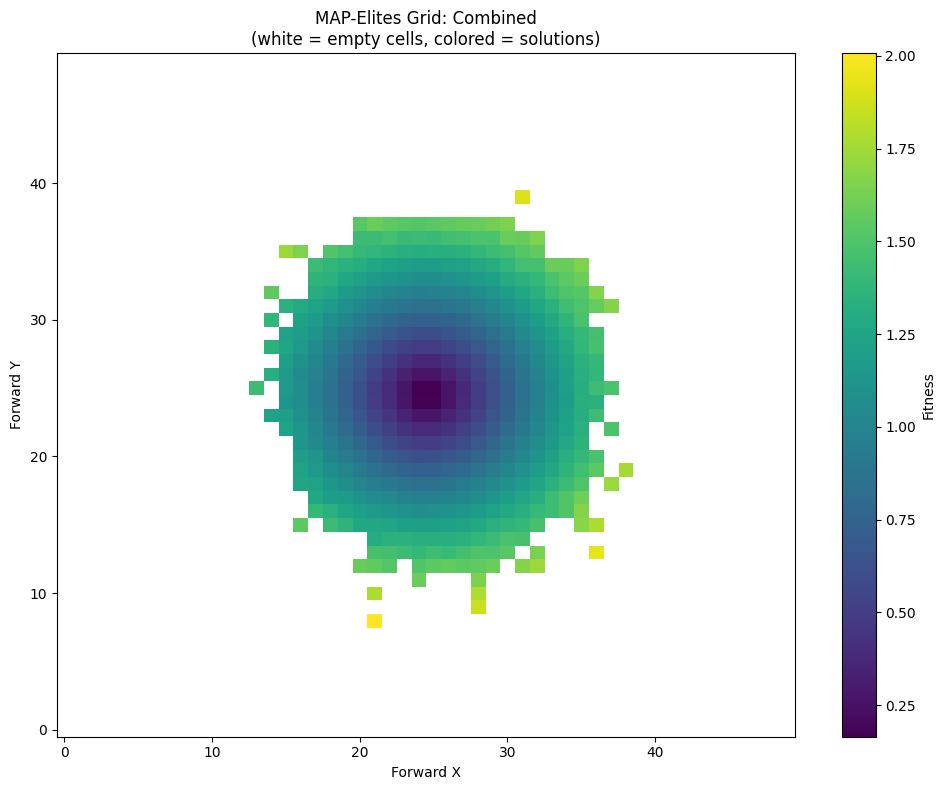


Grid heatmap plotted (white areas = no solutions).


In [7]:
# ==========================================================
# VISUALIZE MAP-ELITES GRID FROM SAVED ARCHIVE
# ==========================================================

import matplotlib.pyplot as plt
import os

# Prefer final archive, fallback to latest checkpoint
final_archive_path = os.path.join(RESULTS_DIR, "map_elites_final.pkl")
checkpoint_files = [
    f for f in os.listdir(CHECKPOINT_DIR)
    if f.startswith('map_elites_iter_') and f.endswith('.pkl')
]

archive_path = None
if os.path.exists(final_archive_path):
    archive_path = final_archive_path
elif checkpoint_files:
    checkpoint_files.sort(key=lambda x: int(x.split('_')[3].split('.')[0]))
    archive_path = os.path.join(CHECKPOINT_DIR, checkpoint_files[-1])

if archive_path is not None:
    print(f"Loading archive: {archive_path}")
    with open(archive_path, 'rb') as f:
        loaded_data = pickle.load(f)

    archive = loaded_data

    print("=" * 60)
    print("MAP-ELITES GRID VISUALIZATION")
    print("=" * 60)

    # Get statistics
    if isinstance(archive, dict) and 'grid' in archive:
        grid = archive.get('grid', {})
        bd_labels = archive.get('bd_labels', ['Dimension 1', 'Dimension 2'])
        fitness_label = archive.get('fitness_label', 'Fitness')
        grid_shape = archive.get('grid_shape', None)

        all_fitnesses = [cell['fitness'] for cell in grid.values()]
        median_fitness = np.median(all_fitnesses) if all_fitnesses else 0.0
        qd_score = sum(all_fitnesses)
        num_filled = len(grid)
        coverage = num_filled / np.prod(grid_shape) if grid_shape else 0.0
        max_fitness = max(all_fitnesses) if all_fitnesses else 0.0
        mean_fitness = np.mean(all_fitnesses) if all_fitnesses else 0.0
    else:
        stats = archive.get_statistics()
        all_fitnesses = [cell['fitness'] for cell in archive.grid.values()]
        median_fitness = np.median(all_fitnesses) if all_fitnesses else 0.0
        qd_score = sum(all_fitnesses)
        num_filled = stats['num_filled']
        coverage = stats['coverage']
        max_fitness = stats['max_fitness']
        mean_fitness = stats['mean_fitness']
        bd_labels = archive.bd_labels
        fitness_label = archive.fitness_label
        grid_shape = archive.grid_shape
        grid = archive.grid

    print(f"Coverage:      {coverage*100:.2f}%")
    print(f"Filled cells:  {num_filled}")
    print(f"Total cells:   {np.prod(grid_shape)}")
    print(f"QD-score:      {qd_score:.4f}")
    print(f"Max fitness:   {max_fitness:.4f}")
    print(f"Mean fitness:  {mean_fitness:.4f}")
    print(f"Median fitness: {median_fitness:.4f}")

    # Create heatmap for 2D behavior descriptors
    if len(grid_shape) == 2:
        heatmap = np.full(grid_shape, np.nan)  # Initialize with NaN (empty cells)
        for grid_idx, cell in grid.items():
            heatmap[grid_idx] = cell['fitness']

        plt.figure(figsize=(10, 8))
        im = plt.imshow(heatmap, cmap='viridis', aspect='auto', origin='lower')
        plt.colorbar(im, label='Fitness')
        plt.xlabel(bd_labels[0])
        plt.ylabel(bd_labels[1])
        plt.title(f"MAP-Elites Grid: {fitness_label}\n(white = empty cells, colored = solutions)")
        plt.tight_layout()
        plt.show()

        print("\nGrid heatmap plotted (white areas = no solutions).")
    else:
        print(f"\n(Grid is {len(grid_shape)}D; heatmap skipped)")
else:
    print(f"No final archive or checkpoints found in {RESULTS_DIR}")


XY Old Distance only

In [7]:
from map_elites.map_elites import MAPElites

# ==========================================================
# PROJECT PATHS (synchronized with config.py)
# ==========================================================

# Prefer canonical paths defined in config.py (experiment_config) if available
PROJECT_ROOT = getattr(experiment_config, 'PROJECT_ROOT', os.getcwd())
RESULTS_DIR = getattr(experiment_config, 'RESULTS_DIR', os.path.join(PROJECT_ROOT, "results"))


# ==========================================================
# CONTROLLER
# ==========================================================

# Controller genome size - prefer value from config module
CONTROLLER_GENOME_SIZE = getattr(experiment_config, 'CONTROLLER_GENOME_SIZE', RecurrentTorqueHexapodController.get_genome_size())

print("=" * 60)
print("PROJECT CONFIGURATION")
print("=" * 60)

print(f"PROJECT_ROOT: {PROJECT_ROOT}")
print(f"URDF_PATH: {getattr(experiment_config, 'URDF_PATH', URDF_PATH)}")
print(f"URDF exists: {os.path.exists(getattr(experiment_config, 'URDF_PATH', URDF_PATH))}")

print(f"Genome size: {CONTROLLER_GENOME_SIZE}")

# ==========================================================
# BEHAVIOR DESCRIPTOR (from config.py) + local fitness configuration
# ==========================================================

BD_MODE = 'xy_position'  # Options: 'xy_position', 'duty_factor', 'transformer_duty_factor', 'transformer_duty_factor_with_goal'
print(f"Behavior Descriptor Mode: {BD_MODE}")

# Keep config.py as the source of truth, but sync its module globals to the notebook choice.
experiment_config.BD_MODE = BD_MODE
experiment_config.TRANSFORMER_BD_CONFIG = (
    experiment_config.get_transformer_bd_config(BD_MODE)
    if BD_MODE.startswith('transformer')
    else None
)

# Fitness configuration is intentionally local to the notebook.
FITNESS_MODE = 'combined'  # Options: 'combined', 'distance', 'forward_velocity', 'avg_speed', 'stability'
DISTANCE_WEIGHT = 5.0 #3.0
AVG_SPEED_WEIGHT = 0.8 #0.3
STABILITY_PENALTY_WEIGHT = 0.05 #0.2
ENERGY_WEIGHT = 2e-8 #2e-6

def get_fitness_name(mode=None):
    if mode is None:
        mode = FITNESS_MODE

    if mode == 'combined':
        return 'Combined'
    elif mode == 'distance':
        return 'Distance_Traveled'
    elif mode == 'forward_velocity':
        return 'Forward_velocity'
    elif mode == 'avg_speed':
        return 'Average_speed'
    elif mode == 'stability':
        return 'Stability_score'
    else:
        raise ValueError(f"Unknown FITNESS_MODE '{mode}'")

# Keep using the functions from config.py.
get_behavior_descriptor_dims = experiment_config.get_behavior_descriptor_dims
get_behavior_descriptor_names = experiment_config.get_behavior_descriptor_names
TRANSFORMER_BD_CONFIG = experiment_config.TRANSFORMER_BD_CONFIG

# ==========================================================
# MAP-ELITES CONFIGURATION (local experiment override)
# ==========================================================

MAP_ELITES_CONFIG = {
    'behavior_descriptors_dims': get_behavior_descriptor_dims(),
    'genome_size': CONTROLLER_GENOME_SIZE,
    'genome_bounds': (-3, 3),
    'num_initial_random': 5000,
    'num_iterations': 5000,
    'batch_size': 64,
    'mutation_rate': 0.005,
    'mutation_strength': 0.08,
    'bd_handling': 'clip' if BD_MODE.startswith('transformer') else 'reject',
    'num_repeated_evaluations': 3,
    'seed': 42,
}
print(behaviour_descriptors_dims := MAP_ELITES_CONFIG['behavior_descriptors_dims'])

# ==========================================================
# LOGGING CONFIGURATION (local experiment override)
# ==========================================================

LOGGING_CONFIG = {
    'save_interval': 500,
    'trajectory_save_interval': 500,
    'save_random_trajectories': False,
    'trajectory_save_probability': 0.1,
    'print_interval': 1000,
    'save_grid': True,
    'save_plots': True,
    'save_detailed_logs': False,
    'num_best_to_log': 20,
    'num_random_to_log': 20,
}

experiment_config.LOGGING_CONFIG = LOGGING_CONFIG

# ==========================================================
# SIMULATION CONFIGURATION (local experiment override)
# ==========================================================

SIMULATION_CONFIG = {
    'duration': 6.0,
    'time_step': 1.0 / 240,
    'gui': False,
    'max_force': 5.0,
    'sample_interval': 1.0,
    'acceleration_threshold': 20.0,
    'warmup_time': 1.0,
    'controller_interval': 4,
}

experiment_name = f"map_elites_{BD_MODE}_{get_fitness_name()}_fitness"
RESULTS_DIR = os.path.join(RESULTS_DIR, experiment_name)
os.makedirs(RESULTS_DIR, exist_ok=True)
CHECKPOINT_DIR = os.path.join(RESULTS_DIR, "checkpoints")
os.makedirs(CHECKPOINT_DIR, exist_ok=True)
RANDOM_TRAJECTORIES_DIR = os.path.join(RESULTS_DIR, "random_trajectories")
os.makedirs(RANDOM_TRAJECTORIES_DIR, exist_ok=True)
DETAILED_LOGS_DIR = os.path.join(RESULTS_DIR, "detailed_logs")
os.makedirs(DETAILED_LOGS_DIR, exist_ok=True)

RESUME = False
CHECKPOINT = os.path.join(
    CHECKPOINT_DIR,
    "map_elites_iter_4500.pkl"
)

start_iteration = 0

if RESUME:
    print(CHECKPOINT)
    start_iteration = 4501

PROJECT CONFIGURATION
PROJECT_ROOT: /home/joze/Mestrado/Dissertacao/Pybullet
URDF_PATH: /home/joze/Mestrado/Dissertacao/Pybullet/robot_models/hexapod.urdf
URDF exists: True
Genome size: 3282
Behavior Descriptor Mode: xy_position
[(-3, 3, 50), (-3, 3, 50)]


In [39]:
# ==========================================================
# CREATE MAP-ELITES
# ==========================================================

map_elites = MAPElites(
    behavior_descriptors_dims=MAP_ELITES_CONFIG['behavior_descriptors_dims'],
    genome_size=MAP_ELITES_CONFIG['genome_size'],
    genome_bounds=MAP_ELITES_CONFIG['genome_bounds'],
    bd_handling=MAP_ELITES_CONFIG['bd_handling'],
    seed=MAP_ELITES_CONFIG['seed'],
)

map_elites.bd_mode = BD_MODE
map_elites.fitness_mode = FITNESS_MODE
map_elites.bd_labels = get_behavior_descriptor_names()
map_elites.fitness_label = get_fitness_name()

# ==========================================================
# INITIAL RANDOM POPULATION
# ==========================================================

initial_population = []

for _ in tqdm(
    range(MAP_ELITES_CONFIG['num_initial_random']),
    desc="Generating initial population"
):
    initial_population.append(map_elites.random_genome())

# ==========================================================
# EVALUATE INITIAL POPULATION
# ==========================================================

fitnesses, bds, final_positions = evaluate_batch_parallel_torque(initial_population)

# ==========================================================
# ADD TO ARCHIVE
# ==========================================================

for genome, fitness, bd, final_position in tqdm(
    zip(initial_population, fitnesses, bds, final_positions),
    desc="Adding initial population to archive",
    total=len(initial_population)
):
    map_elites.add_to_grid(genome, fitness, bd, final_position=final_position)

# ==========================================================
# INITIAL STATS
# ==========================================================

stats = map_elites.get_statistics()

print("\nInitial archive statistics:\n")

for k, v in stats.items():
    print(f"{k}: {v}")

# ==========================================================
# TIMER
# ==========================================================

start_time = time.time()

Adding initial population to archive: 100%|██████████| 5000/5000 [00:00<00:00, 264181.50it/s]


Initial archive statistics:

coverage: 0.0084
num_filled: 21
max_fitness: 0.344528018810378
mean_fitness: 0.24357500831706014
qd_score: 5.115075174658263


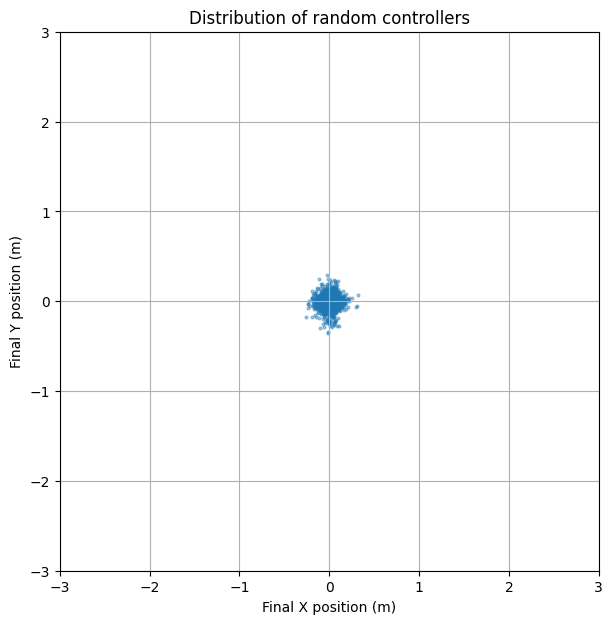

Unique cells visited: 21
Archive cells: 2500
Coverage from random controllers: 0.84%


In [40]:
import matplotlib.pyplot as plt
import numpy as np

bds = np.asarray(bds)

plt.figure(figsize=(7, 7))
plt.scatter(
    bds[:, 0],
    bds[:, 1],
    s=4,
    alpha=0.4
)

plt.xlabel("Final X position (m)")
plt.ylabel("Final Y position (m)")
plt.title("Distribution of random controllers")

# Show archive limits
x_low, x_high, _ = MAP_ELITES_CONFIG['behavior_descriptors_dims'][0]
y_low, y_high, _ = MAP_ELITES_CONFIG['behavior_descriptors_dims'][1]

plt.xlim(x_low, x_high)
plt.ylim(y_low, y_high)

plt.grid(True)
plt.gca().set_aspect('equal')

plt.show()

visited_cells = set()

for bd in bds:
    norm_bd = map_elites.process_behavior_descriptors(bd)

    if norm_bd is None:
        continue

    idx = map_elites.get_grid_index(norm_bd)

    if idx is not None:
        visited_cells.add(tuple(idx))

print(f"Unique cells visited: {len(visited_cells)}")
print(f"Archive cells: {map_elites.get_total_cells()}")
print(f"Coverage from random controllers: "
      f"{100*len(visited_cells)/map_elites.get_total_cells():.2f}%")

In [41]:
# ==========================================================
# CELL 2 — MAIN EVOLUTION LOOP
# ==========================================================

sim_for_logging = HexapodTorqueSimulation(
    urdf_path=URDF_PATH,
    gui=False,
    time_step=SIMULATION_CONFIG['time_step'],
)

for iteration in tqdm(
    range(MAP_ELITES_CONFIG['num_iterations']),
    desc="Iterations"
 ):

    # ------------------------------------------------------
    # SAMPLE PARENTS
    # ------------------------------------------------------

    parents = []

    for _ in tqdm(
        range(MAP_ELITES_CONFIG['batch_size']),
        desc="Selecting parents",
        leave=False
    ):
        parents.append(map_elites.random_selection())

    # ------------------------------------------------------
    # MUTATE
    # ------------------------------------------------------

    offspring = []

    for parent in tqdm(
        parents,
        desc="Mutating parents",
        leave=False
    ):

        child = map_elites.mutate(
            genome=parent,
            mutation_rate=MAP_ELITES_CONFIG['mutation_rate'],
            mutation_strength=MAP_ELITES_CONFIG['mutation_strength']
        )

        offspring.append(child)

    # ------------------------------------------------------
    # EVALUATE OFFSPRING
    # ------------------------------------------------------

    fitnesses, bds, final_positions = evaluate_batch_parallel_torque(offspring)

    # ------------------------------------------------------
    # ADD TO ARCHIVE
    # ------------------------------------------------------

    for genome, fitness, bd, final_position in tqdm(
        zip(offspring, fitnesses, bds, final_positions),
        desc="Adding offspring to archive",
        total=len(offspring),
        leave=False
    ):
        map_elites.add_to_grid(genome, fitness, bd, final_position=final_position)

    # ------------------------------------------------------
    # UPDATE HISTORY
    # ------------------------------------------------------

    map_elites.update_history()

    # ------------------------------------------------------
    # CHECKPOINT
    # ------------------------------------------------------

    if iteration % LOGGING_CONFIG['save_interval'] == 0:

        checkpoint_path = os.path.join(
            CHECKPOINT_DIR,
            f"map_elites_iter_{iteration}.pkl"
        )

        map_elites.save(checkpoint_path)

        if LOGGING_CONFIG.get('save_detailed_logs', False):
            save_detailed_logs_snapshot(
                map_elites,
                sim_for_logging,
                iteration=iteration,
                num_best=LOGGING_CONFIG.get('num_best_to_log', 20),
            )

        stats = map_elites.get_statistics()

        elapsed = time.time() - start_time

        print("\n================================================")
        print(f"Iteration: {iteration}")
        print("================================================")
        print(f"Coverage:      {stats['coverage']:.4f}")
        print(f"Filled cells:  {stats['num_filled']}")
        print(f"Max fitness:   {stats['max_fitness']:.4f}")
        print(f"QD score:      {stats['qd_score']:.4f}")
        print(f"Elapsed:       {elapsed/60:.2f} min")
        print("================================================\n")

# ==========================================================
# SAVE FINAL ARCHIVE
# ==========================================================

final_archive_path = os.path.join(RESULTS_DIR, "map_elites_final.pkl")
map_elites.save(final_archive_path)
print(f"Final archive saved to: {final_archive_path}")

if LOGGING_CONFIG.get('save_detailed_logs', False):
    save_detailed_logs_snapshot(
        map_elites,
        sim_for_logging,
        iteration='final',
        num_best=LOGGING_CONFIG.get('num_best_to_log', 20),
    )

final_stats = map_elites.get_statistics()
print("\nFinal archive statistics:\n")
for k, v in final_stats.items():
    print(f"{k}: {v}")

sim_for_logging.disconnect()

Iterations:   0%|          | 1/5000 [00:06<8:44:49,  6.30s/it]


Iteration: 0
Coverage:      0.0092
Filled cells:  23
Max fitness:   0.5245
QD score:      5.9652
Elapsed:       0.11 min



Iterations:  10%|█         | 501/5000 [45:39<6:49:16,  5.46s/it]


Iteration: 500
Coverage:      0.0524
Filled cells:  131
Max fitness:   1.1165
QD score:      77.7750
Elapsed:       45.66 min



Iterations:  20%|██        | 1001/5000 [1:30:26<5:53:39,  5.31s/it]

...


Iteration: 4000
Coverage:      0.3036
Filled cells:  759
Max fitness:   2.4699
QD score:      1087.5371
Elapsed:       348.78 min



Iterations:  90%|█████████ | 4501/5000 [6:30:54<41:32,  4.99s/it]  


Iteration: 4500
Coverage:      0.3268
Filled cells:  817
Max fitness:   2.5446
QD score:      1204.9837
Elapsed:       390.91 min



Iterations: 100%|██████████| 5000/5000 [7:12:52<00:00,  5.19s/it]

Final archive saved to: /home/joze/Mestrado/Dissertacao/Pybullet/results/map_elites_xy_position_Combined_fitness/map_elites_final.pkl

Final archive statistics:

coverage: 0.3512
num_filled: 878
max_fitness: 2.6929712466074682
mean_fitness: 1.519742120581449
qd_score: 1334.3335818705123


Loading archive: /home/joze/Mestrado/Dissertacao/Pybullet/results/map_elites_xy_position_Combined_fitness/map_elites_final.pkl
MAP-ELITES GRID VISUALIZATION
Coverage:      18.92%
Filled cells:  473
Total cells:   2500
QD-score:      494.9593
Max fitness:   1.7716
Mean fitness:  1.0464
Median fitness: 1.0993


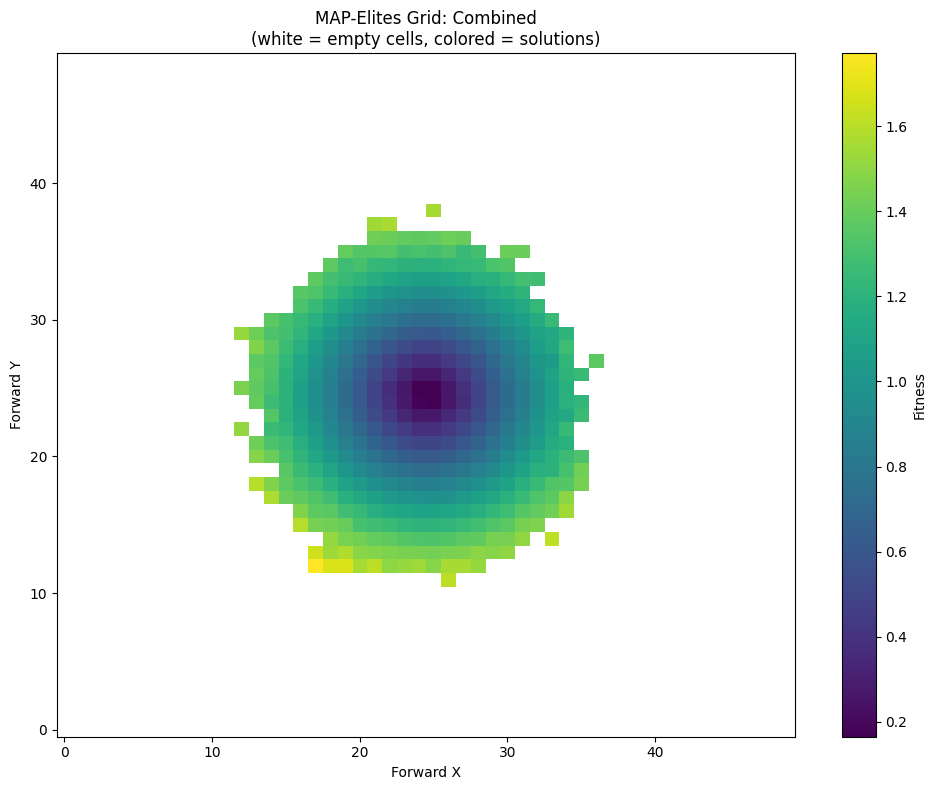


Grid heatmap plotted (white areas = no solutions).


In [8]:
# ==========================================================
# VISUALIZE MAP-ELITES GRID FROM SAVED ARCHIVE
# ==========================================================

import matplotlib.pyplot as plt
import os

# Prefer final archive, fallback to latest checkpoint
final_archive_path = os.path.join(RESULTS_DIR, "map_elites_final.pkl")
checkpoint_files = [
    f for f in os.listdir(CHECKPOINT_DIR)
    if f.startswith('map_elites_iter_') and f.endswith('.pkl')
]

archive_path = None
if os.path.exists(final_archive_path):
    archive_path = final_archive_path
elif checkpoint_files:
    checkpoint_files.sort(key=lambda x: int(x.split('_')[3].split('.')[0]))
    archive_path = os.path.join(CHECKPOINT_DIR, checkpoint_files[-1])

if archive_path is not None:
    print(f"Loading archive: {archive_path}")
    with open(archive_path, 'rb') as f:
        loaded_data = pickle.load(f)

    archive = loaded_data

    print("=" * 60)
    print("MAP-ELITES GRID VISUALIZATION")
    print("=" * 60)

    # Get statistics
    if isinstance(archive, dict) and 'grid' in archive:
        grid = archive.get('grid', {})
        bd_labels = archive.get('bd_labels', ['Dimension 1', 'Dimension 2'])
        fitness_label = archive.get('fitness_label', 'Fitness')
        grid_shape = archive.get('grid_shape', None)

        all_fitnesses = [cell['fitness'] for cell in grid.values()]
        median_fitness = np.median(all_fitnesses) if all_fitnesses else 0.0
        qd_score = sum(all_fitnesses)
        num_filled = len(grid)
        coverage = num_filled / np.prod(grid_shape) if grid_shape else 0.0
        max_fitness = max(all_fitnesses) if all_fitnesses else 0.0
        mean_fitness = np.mean(all_fitnesses) if all_fitnesses else 0.0
    else:
        stats = archive.get_statistics()
        all_fitnesses = [cell['fitness'] for cell in archive.grid.values()]
        median_fitness = np.median(all_fitnesses) if all_fitnesses else 0.0
        qd_score = sum(all_fitnesses)
        num_filled = stats['num_filled']
        coverage = stats['coverage']
        max_fitness = stats['max_fitness']
        mean_fitness = stats['mean_fitness']
        bd_labels = archive.bd_labels
        fitness_label = archive.fitness_label
        grid_shape = archive.grid_shape
        grid = archive.grid

    print(f"Coverage:      {coverage*100:.2f}%")
    print(f"Filled cells:  {num_filled}")
    print(f"Total cells:   {np.prod(grid_shape)}")
    print(f"QD-score:      {qd_score:.4f}")
    print(f"Max fitness:   {max_fitness:.4f}")
    print(f"Mean fitness:  {mean_fitness:.4f}")
    print(f"Median fitness: {median_fitness:.4f}")

    # Create heatmap for 2D behavior descriptors
    if len(grid_shape) == 2:
        heatmap = np.full(grid_shape, np.nan)  # Initialize with NaN (empty cells)
        for grid_idx, cell in grid.items():
            heatmap[grid_idx] = cell['fitness']

        plt.figure(figsize=(10, 8))
        im = plt.imshow(heatmap, cmap='viridis', aspect='auto', origin='lower')
        plt.colorbar(im, label='Fitness')
        plt.xlabel(bd_labels[0])
        plt.ylabel(bd_labels[1])
        plt.title(f"MAP-Elites Grid: {fitness_label}\n(white = empty cells, colored = solutions)")
        plt.tight_layout()
        plt.show()

        print("\nGrid heatmap plotted (white areas = no solutions).")
    else:
        print(f"\n(Grid is {len(grid_shape)}D; heatmap skipped)")
else:
    print(f"No final archive or checkpoints found in {RESULTS_DIR}")


In [9]:
# ==========================================================
# EXPORT TOP SOLUTIONS TO STANDALONE VISUALIZATION SCRIPT
# ==========================================================

import json

if 'archive' in globals():
    num_to_visualize = 5  # Export top 5 solutions

    # Extract grid from archive
    if isinstance(archive, dict) and 'grid' in archive:
        grid = archive.get('grid', {})
    else:
        grid = archive.grid

    # Sort cells by fitness (descending)
    sorted_cells = sorted(
        grid.items(),
        key=lambda x: x[1]['fitness'],
        reverse=True
    )

    top_cells = sorted_cells[:num_to_visualize]

    # Prepare data for export
    solutions_data = {
        'solutions': [],
        'config': {
            'urdf_path': URDF_PATH,
            'duration': SIMULATION_CONFIG['duration'],
            'time_step': SIMULATION_CONFIG['time_step'],
            'sample_interval': SIMULATION_CONFIG['sample_interval'],
        }
    }

    print(f"Exporting top {len(top_cells)} solutions...")
    print("=" * 60)

    for rank, (grid_idx, cell) in enumerate(top_cells, 1):
        genome = cell['genome']
        fitness = cell['fitness']
        bd = cell['bd']

        print(f"[{rank}] Fitness: {fitness:.4f}, BD: {bd}, Grid: {grid_idx}")

        solutions_data['solutions'].append({
            'rank': rank,
            'grid_idx': grid_idx,
            'fitness': float(fitness),
            'bd': bd.tolist() if hasattr(bd, 'tolist') else bd,
            'genome': genome.tolist() if hasattr(genome, 'tolist') else genome,
        })

    # Save to JSON file
    export_path = os.path.join(RESULTS_DIR, 'top_solutions.json')
    with open(export_path, 'w') as f:
        json.dump(solutions_data, f, indent=2)

    print("\n" + "=" * 60)
    print(f"Solutions exported to: {export_path}")
    print("\nTo visualize, run:")
    print("  ./bulletenv/bin/python visualize_top_solutions.py")
else:
    print("No archive loaded. Run the previous visualization/load cell first.")


Exporting top 5 solutions...
[1] Fitness: 1.7716, BD: [0.24783991 0.34968835], Grid: (12, 17)
[2] Fitness: 1.6847, BD: [0.24211952 0.38808867], Grid: (12, 19)
[3] Fitness: 1.6827, BD: [0.24612688 0.3799884 ], Grid: (12, 18)
[4] Fitness: 1.6545, BD: [0.264157  0.3576312], Grid: (13, 17)
[5] Fitness: 1.6151, BD: [0.28526518 0.6610905 ], Grid: (14, 33)

Solutions exported to: /home/joze/Mestrado/Dissertacao/Pybullet/results/map_elites_xy_position_Combined_fitness/top_solutions.json

To visualize, run:
  ./bulletenv/bin/python visualize_top_solutions.py


In [ ]:
from controllers.hexapod_controller_final import RecurrentTorqueHexapodController
from simulation.simulation_final import HexapodTorqueSimulation

# Open a separate GUI simulation so the random robot is visible even if the
# main experiment notebook was created in headless mode.
gui_sim = HexapodTorqueSimulation(
    urdf_path=URDF_PATH,
    gui=True,
    time_step=SIMULATION_CONFIG['time_step'],
)

random_genome = RecurrentTorqueHexapodController.random_genome()
print(f"Random genome size: {random_genome.size}")
print("Rendering a random robot in the PyBullet GUI...")

try:
    result = gui_sim.evaluate_controller(
        random_genome,
        duration=5.0,
        warmup_time=SIMULATION_CONFIG.get('warmup_time', 2.0),
        render=True,
        controller_interval=SIMULATION_CONFIG.get('controller_interval', 4),
        log_all_steps=False,
    )

    print(f"Fitness: {result['fitness']:.4f}")
    print(f"Behavior descriptors: {result['behavior_descriptors']}")
finally:
    gui_sim.disconnect()

Random genome size: 3282
Rendering a random robot in the PyBullet GUI...
startThreads creating 1 threads.
starting thread 0
started thread 0 
argc=2
argv[0] = --unused
argv[1] = --start_demo_name=Physics Server
ExampleBrowserThreadFunc started
X11 functions dynamically loaded using dlopen/dlsym OK!
X11 functions dynamically loaded using dlopen/dlsym OK!
Creating context
Created GL 3.3 context
Direct GLX rendering context obtained
Making context current
GL_VENDOR=Microsoft Corporation
GL_RENDERER=D3D12 (Intel(R) Iris(R) Xe Graphics)
GL_VERSION=4.1 (Core Profile) Mesa 23.2.1-1ubuntu3.1~22.04.3
GL_SHADING_LANGUAGE_VERSION=4.10
pthread_getconcurrency()=0
Version = 4.1 (Core Profile) Mesa 23.2.1-1ubuntu3.1~22.04.3
Vendor = Microsoft Corporation
Renderer = D3D12 (Intel(R) Iris(R) Xe Graphics)
b3Printf: Selected demo: Physics Server
startThreads creating 1 threads.
starting thread 0
started thread 0 
MotionThreadFunc thread started
ven = Microsoft Corporation
ven = Microsoft Corporation
